# Initialization

In [1]:
from gradient_estimation_helpers import *

# TODO: remove this
%load_ext autoreload
%autoreload 2

In [2]:
# TODO: small fixes along the notebook
# TODO: code fix - free the ancilla after using it
# TODO: clean up the explanations and add references to the paper
# TODO: clean up section 4 (Parameters selection)
# TODO: check all or's comments from github and make sure they are addressed
# TODO: add tests

# Fast Quantum Algorithm for Numerical Gradient Estimation
> Given a scalar function of $d$ dimensions, $f(x_1, ... x_d)$, it is useful to find the gradient of the function at a specific point.\
> On a classical computer, this requires at least d+1 queries of the function $f$.\
> In this notebook we will explore quantum algorithm to find the gradient with just a single query of the function.\
> This is a dramatic improvement in large dimensions functions, as most of the times the most expensive part of calculating the derivative is querying the function.
> * **Input:** A black box function $f$ of $d$ variables.
> * **Promise:** The function is a smooth real scalar function, and the gradient is bounded with a known value $|\nabla f|<\nabla f_{\text{max}}$.
> * **Output:** The gradient $\nabla f$ at the origin with $n$ bits of precision.

> **Complexity:** In the context of many numerical calculations, black-box query complexity is a natural measure of algorithmic efficiency. In this measure, the classical algorithm queries the function at least $d+1$ times, while the quantum algorithm only queries the function a single time.


The core concept of the algorithm is to first 'apply' the function to the phase of a superposition state, then extract the gradient value from the phase to a measurable state by using a QFT.\
Let's see it step by step, first a little simplified version to understand the concept, and then fixing the inaccuracies for the final algorithm.\
![Quantum Circuit](quantum_circuit.png)\
**TODO:** Decide which image to use, with or without the ancilla\
![Quantum Circuit](quantum_circuit_2.png)

## Simplified explanation of the algorithm
As briefly mentioned earlier, the algorithm can be divided to two steps:
1. Applying the function to the phase
2. Extracting the gradient value to a measurable state

In more details:
1. For each coordinate ($x_i$), we start with the state $|\delta_i\rangle=|0\rangle+|1\rangle+|2\rangle....|N-1\rangle$, by applying the Hadamard gate on $|0\rangle$.\
For simplicity we will discuss a case of single coordinate, but if there is more than one coordinate, the state $|\delta\rangle$ is just a product state of all $|\delta_i\rangle$, and the algorithm stays the same.
$$|\delta\rangle=\prod_i|\delta_i\rangle$$
2. Using the phase kickback technique, we apply the function to the phase of each ket creating the state:
$$e^{i\cdot2\pi f(0)}|0\rangle + e^{i\cdot2\pi f(1)}|1\rangle + e^{i\cdot2\pi f(2)}|2\rangle ..... e^{i\cdot2\pi f(N-1)}|N-1\rangle$$
**TODO**: Decide to keep, move or remove those images
![](step_2.png)\
3. We note the fact that for small enough interval, we can approximate: $f(x)\approx f(0)+x\cdot f'(x)$, so we can write the previous state as: 
$$ e^{i\cdot2\pi f(0)}(|0\rangle + e^{i\cdot2\pi f'(0)}|1\rangle + e^{i\cdot2\pi 2f'(0)}|2\rangle ..... e^{i\cdot2\pi (N-1)f'(0)}|N-1\rangle) = e^{i\cdot2\pi f(0)}\sum e^{i\cdot2\pi jf'(0)}|j\rangle $$
![](step_3.png)\
4. We note that this state is exactly the fourier transform of the state $|f'(0)\rangle$, so we apply the inverse fourier transform and get the result: $$|f'(0)\rangle$$
5. We measure to get $f'(0)$, and for a multi-coordinates function $\nabla f$.



## Full explanation of the algorithm
The previous explanation covers the main idea of the algorithm, but misses some important details on negative and fractional values.\
In this explanation we will fill in these details.\
When we calculate gradient, we look on an interval around the point of interest (in this case, it will be the origin). We will call this interval $l$.
The state $|\delta_i\rangle$ should represent $N$ equally spaced points around the origin in the interval $l$, so we normalized it to be:
$$ x=\frac{l}{N}\delta $$
With signed $\delta$ ranging from $-N/2$ to $N/2-1$: $\delta=-N/2$ is the leftmost point ($-l/2$), $\delta=0$ is the origin, and $\delta=N/2-1$ is the rightmost point ($l/2$)*.\
\
We also need to normalize the result state. Say the expected gradient is bounded between $-m/2$ and $m/2$, we want to represent those values using the $N$ states of the coordinate, so doing a similar trick we can define $$ \nabla f=\frac{m}{N}\delta_{measured} $$\
\
When using the algorithm we need to select $l$ and $m$ using our prior knowledge on the function $f(x)$, and $N$ will define the final resolution we get.\
$l$ should be small enough so we will stay in a linear regime of the function, and $m$ should be larger than the maximum possible gradient, but not too large because then we will lose resolution.
\
Using those two normalizations, we change two things in the algorithm:
1. In step 2, instead of applying $f(\delta)$, we apply $\frac{N}{ml}f(\frac{l}{N}\delta)$.
2. In step 5, the signed measurement directly gives $\frac{N}{m}\nabla f$, so $\nabla f = \frac{m}{N}\delta_{measured}$.
Using a signed register means the measured $\delta_{measured}$ is already the correct signed value with no further adjustment needed.\

\* The right point is actually $l/2-l/N$ and not $l/2$, because the center point is at the origin and $N$ must be even, but for the  algorithm understanding it doesn't really matter.

## Parameter Selection
As briefly discussed before, we need to select appropriate values for $l$, $m$ and $N$ (and when using the ancilla method, also $N_0$, but we will not discuss it here).\
Let's define: 
* $\nabla f_{max}$ - a bound for the value of $\nabla f$ in the region around the origin, $|\nabla f|<\nabla f_{max}$
* $\epsilon$ - desired accuracy for $\nabla f$ estimation, $|\nabla f_{est}-\nabla f| < \epsilon$
* $d$ - the dimensionality of the function $f$
* $D_2$ - typical value for the second derivative of $f$

### Selecting $l$
Starting with $l$, this is the interval around the origin for the gradient estimation. Exactly like in classical gradient calculation, the interval should be small enough that we will be in the linear regime of the function.\
If we want to reach accuracy $\epsilon$, we need the gradient inside the interval to have smaller variance than $\epsilon$, meaning $max(\nabla f)-min(\nabla f)<\epsilon$. Using the second derivative approximation $max(\nabla f)-min(\nabla f)\approx|\nabla^2 f|\cdot l<\epsilon$, meaning we have to select $l$ such that $l<\frac{\epsilon}{|\nabla^2 f|}$.\
For example, for a quadratic function $f(x)=ax^2+bx+c$, $l$ should be smaller than the order of $\frac{\epsilon}{2a}$.\
**TODO**: This isn't accurate, use the paper's more accurate result giving $l\leq\frac{2\sqrt{3}\epsilon}{D_2\sqrt{d}}$.

### Selecting $m$
$m$ is exactly defined as the bound for the value of the gradient. If we want to calculate a gradient that might be negative, there is a $1/2$ factor so $m\ge2\cdot\nabla f_{max}$.

### Selecting $N$
$N$ defines the resolution of the final result. The step size between possible results is $\frac{m}{N}$.\
Therefore, in order to achieve accuracy $\epsilon$, we need to choose $N\ge0.5\frac{m}{\epsilon}$.\
Plugging in the condition for $m$, we get $N\ge\frac{\nabla f_{max}}{\epsilon}$.

### Summery
Given a known bound $\nabla f_{max}$ and desired accuracy $\epsilon$, we can select the parameters:
$$\left\{\begin{aligned}
l & \leq \frac{2 \sqrt{3} \epsilon}{D_2 \sqrt{d}} \\
m & \geq 2 \nabla f_{\max } \\
N & \geq \frac{\nabla f_{\max }}{\epsilon}
\end{aligned}\right.$$

## Notebook's structure:
In the notebook, we will cover those topics:
1. Theoretical explanation (this section)
2. Step 1 of the algorithm - State Preparation. We will cover two methods. Phase Kickback (as in the cited paper) and Direct Phase (more straight forward and more efficient for the simulation). We will demonstrate how the states are prepared using a full statevector simulation.
3. The full algorithm, showing examples of linear and non-linear functions.
4. Parameters selection and limits (Still work in progress)
5. Multi-coordinates example, $f$ as function of $x, y$


# 2. State Preparation

## 2.1. Phase Kickback

The first step of the algorithm is to prepare the state:
$$\sum_{\delta}e^{i2\pi\frac{N}{ml}f(\frac{l}{N}\delta)}|\delta\rangle$$
The paper uses the phase kickback technique using the ancilla in order to create this state.\
In the next example we will see how it works.

The phase kickback contains three steps:
1. Apply Hadamard gate on $|\delta\rangle$ to have an entangled state
2. Set the ancilla to $|1111...1\rangle$ (in binary representation) and apply QFT on it
3. Add the value $f(\delta)$ to the ancilla, and the function's value will be 'kicked' to the phase

Note that we use the ancilla as a signed and fractional QNum, so in order to have $|1111...1_b\rangle$, we will assign $-1/N_0$

In [3]:
# Set the default values:
# l = 0.5, m = 2, n = 3, n0 = 3
p = params()

# Set the function we want to calculate the gradient of:
# f(x) = 0.5*x + 0.25
# Gradient: f'(0) = 0.5
p.set_function(p.linear, (0.5, 0.25))

# Unpack the parameters to global variables for easier use
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]], ancilla: Output[QNum[n0, SIGNED, n0]]):
    # 1. State preparation

    # 1.1. Set the coordinates state - Apply Hadamard gate on the coordinates register
    allocate(n, x)
    hadamard_transform(x)

    # 1.2. Set the ancilla state - Apply QFT to |1111...1> state
    probabilities = [0] * (N0 - 1) + [1]  # |1111...1> state
    prepare_state(probabilities=probabilities, bound=0.01, out=ancilla)
    qft(ancilla)

    # 1.3. Apply the function f on the ancilla, to create the phase kickback
    # Calculate the normalized f and add it to the ancilla
    val = f_normalized(x)
    inplace_add(val, ancilla)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))


# Run using a statevector simulator
qprog = synthesize(main)
# show(qprog) # Uncomment to see the circuit
print("Circuit Width:", qprog.data.width)
print("Circuit Depth:", qprog.transpiled_circuit.depth)
print("Gate Counts:", qprog.transpiled_circuit.count_ops)

# Pay attention that we use a statevector simulator here
backend_preferences = ClassiqBackendPreferences(backend_name="simulator_statevector")
execution_preferences = ExecutionPreferences(
    num_shots=1, backend_preferences=backend_preferences
)
with ExecutionSession(qprog, execution_preferences=execution_preferences) as es:
    es.set_measured_state_filter("ancilla", lambda v: v == 0)
    results_statevector = es.sample()

# Show the results as a dataframe.
df = results_statevector.dataframe
df

# From now on, we will use the shortcut function:
# df = run_statevector_simulation(main, print_circuit_info=True, filter_ancilla=True)

Circuit Width: 7
Circuit Depth: 30
Gate Counts: {'u': 25, 'cx': 19}


,x,ancilla,amplitude,magnitude,phase,probability,bitstring
0,3,0.0,0.088388-0.088388j,0.12,-0.25π,0.015625,0000011
1,1,0.0,-0.088388+0.088388j,0.12,0.75π,0.015625,0000001
2,-3,0.0,-0.088388+0.088388j,0.12,0.75π,0.015625,0000101
3,-1,0.0,0.088388-0.088388j,0.12,-0.25π,0.015625,0000111
4,2,0.0,-0.088388-0.088388j,0.12,-0.75π,0.015625,0000010
5,0,0.0,0.088388+0.088388j,0.12,0.25π,0.015625,0000000
6,-2,0.0,-0.088388-0.088388j,0.12,-0.75π,0.015625,0000110
7,-4,0.0,0.088388+0.088388j,0.12,0.25π,0.015625,0000100


In order to understand the results, let's focus on the phase compared to the classical value of f(x):

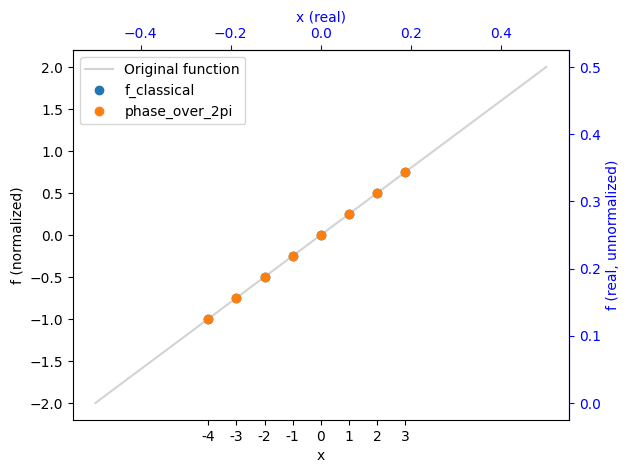

,f_classical,phase_over_2pi
x,,
-4,-1.00,-1.00
-3,-0.75,-0.75
-2,-0.50,-0.50
-1,-0.25,-0.25
0,0.00,0.00
1,0.25,0.25
2,0.50,0.50
3,0.75,0.75


In [4]:
# Shift the classical function to match the quantum convention
f_classical = f_normalized(df["x"]) - f_normalized(0)
# Create a simplified dataframe with the relevant information, and sort it by the x values.
phases = np.angle(df["amplitude"]).astype(float)
phases_over_2pi = phases / (2 * np.pi)
simplified_df = pd.DataFrame(
    {"f_classical": f_classical, "phase_over_2pi": phases_over_2pi.round(5)}
)
simplified_df.index = df["x"]
simplified_df.sort_index(inplace=True)
# Unwrap the phase
simplified_df["phase_over_2pi"] = np.unwrap(simplified_df["phase_over_2pi"], period=1)
# Get rid of the global phase
simplified_df["phase_over_2pi"] -= simplified_df["phase_over_2pi"].iloc[N // 2]
simplified_df["f_classical"] -= simplified_df["f_classical"].iloc[N // 2]

# Plot the results
plt.figure()
plot_classical()
simplified_df.plot(style="o", ax=plt.gca())
plt.legend()
plt.show()

# Show the results as a dataframe
simplified_df

In the graph we can see the original function (gray line), the classical values and the quantum phase at the chosen points (classical - blue, quantum - orange).\
Everything in both normalized values (black axes), and the original values (blue axes).

For convenience, the full code to generate this graph:

Circuit Width: 8
Circuit Depth: 42
Gate Counts: {'u': 31, 'cx': 27}


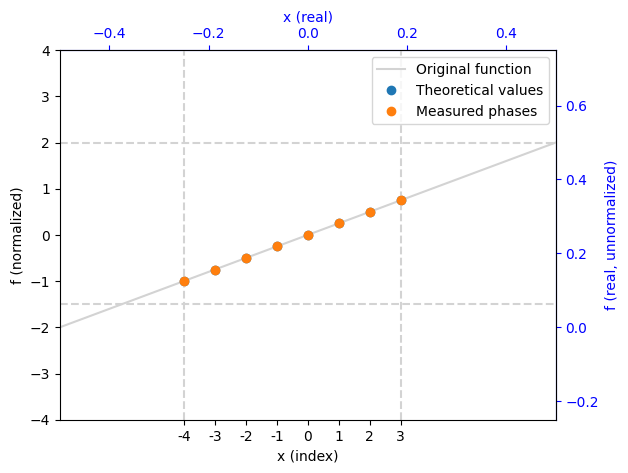

In [5]:
p = params()
# f(x) = 0.5*x + 0.25
# Gradient: f'(0) = 0.5
p.set_function(p.linear, (0.5, 0.25))
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]], ancilla: Output[QNum[n0, SIGNED, n0]]):
    # 1. State preparation

    # 1.1. Set the coordinates state - Apply Hadamard gate on the coordinates register
    allocate(n, x)
    hadamard_transform(x)

    # 1.2. Set the ancilla state - Apply QFT to |1111...1> state
    probabilities = [0] * (N0 - 1) + [1]  # |1111...1> state
    prepare_state(probabilities=probabilities, bound=0.01, out=ancilla)
    qft(ancilla)

    # 1.3. Apply the function f on the ancilla, to create the phase kickback
    # Calculate the normalized f and add it to the ancilla
    val = f_normalized(x)
    inplace_add(val, ancilla)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))


df = run_statevector_simulation(main, print_circuit_info=True, filter_ancilla=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

In [6]:
# # TODO: Fix it and remove the original (Ancilla not as output)
# p = params()
# # f(x) = 0.5*x + 0.25
# # Gradient: f'(0) = 0.5
# p.set_function(p.linear, (0.5, 0.25))
# p.unpack(globals())

# @qfunc
# def main(x: Output[QNum[n, SIGNED, 0]]):
#     # 1. State preparation

#     # 1.1. Set the coordinates state - Apply Hadamard gate on the coordinates register
#     allocate(n, x)
#     hadamard_transform(x)

#     # 1.2. Set the ancilla state - Apply QFT to |1111...1> state
#     ancilla = QNum("ancilla", n0, SIGNED, n0) # Declare the name/type
#     probabilities = [0] * (N0-1) + [1] # |1111...1> state
#     prepare_state(probabilities=probabilities, bound=0.01, out=ancilla)
#     qft(ancilla)

#     # 1.3. Apply the function f on the ancilla, to create the phase kickback
#     # Calculate the normalized f and add it to the ancilla
#     val = f_normalized(x)
#     inplace_add(val, ancilla)
#     invert(lambda: qft(ancilla))
#     drop(ancilla)

#     # 2. Next step in the algorithm: QFT inverse on the coordinates register
#     invert(lambda: qft(x))

# df = run_statevector_simulation(main, print_circuit_info=True, filter_ancilla=True)
# simplified_df = simplify_df(df)
# plot_simplified_df(simplified_df)

## 2.2. Direct Phase

The phase kickback approach is good when we have a state-oracle, but in our simulation it is very inefficient.

Another approach is to directly prepare the wanted state.
In our case:
$$\sum_{\delta}e^{i2\pi\frac{N}{ml}f(\frac{l}{N}\delta)}|\delta\rangle$$

Here we can see the same example using the prepare_complex_amplitudes function.\
You can look at the circuit width/depth and gate count to compare both methods.\
In real applications, both methods can be used, depending on the oracle f.

Circuit Width: 3
Circuit Depth: 1
Gate Counts: {'u': 3}


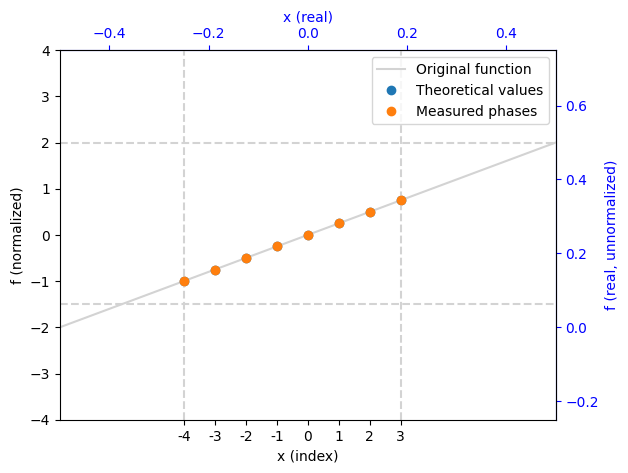

In [7]:
p = params()
# f(x) = 0.5*x + 0.25
# Gradient: f'(0) = 0.5
p.set_function(p.linear, (0.5, 0.25))
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))


df = run_statevector_simulation(main, print_circuit_info=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

The graph is exactly the same as the phase kickback method.\
From this point, we will use this method over the phase kickback, in order to have better efficiency.

## 2.3. Quadratic Function

More interesting are non-linear functions.\
In the next example we will see a quadratic function.\
Note that the 'magic' does not happen in this step. You will see that the phases agree with the function completely and doesn't do the linearization needed to calculate the gradient. The magic will happen in the next step where the QFT will do the linearization for us.

Circuit Width: 3
Circuit Depth: 9
Gate Counts: {'u': 6, 'cx': 6}


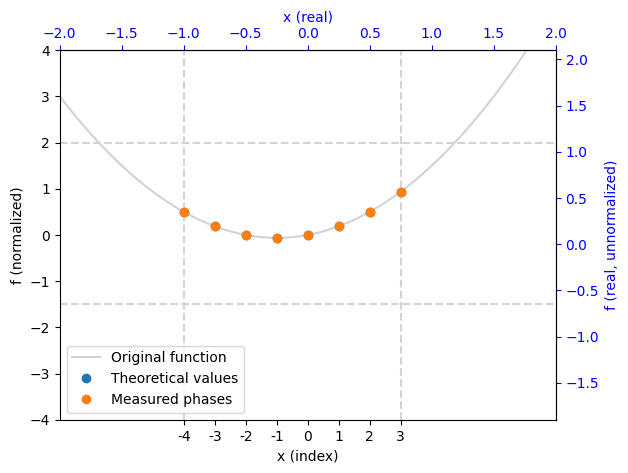

In [8]:
p = params()
# f(x) = 0.5*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.5, 0.25, 0.1))
p.l = 2
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))


df = run_statevector_simulation(main, print_circuit_info=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

If we decrease $l$, we look at the function more closely, and it is closer to linear.

Circuit Width: 3
Circuit Depth: 9
Gate Counts: {'u': 6, 'cx': 6}


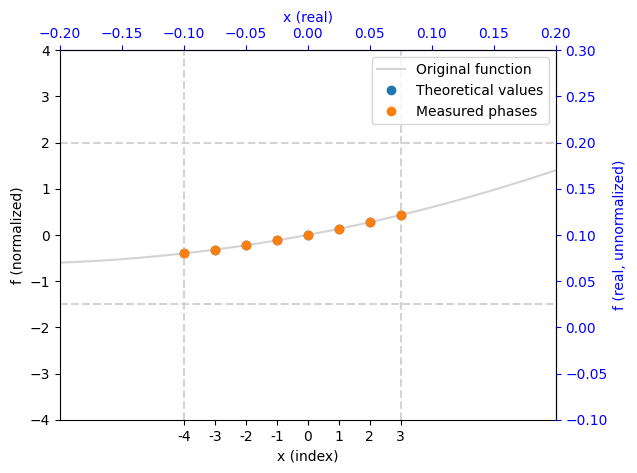

In [9]:
p = params()
# f(x) = 0.5*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.5, 0.25, 0.1))
p.l = 0.2
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    # invert(lambda: qft(x))


df = run_statevector_simulation(main, print_circuit_info=True)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)

# 3. Full Algorithm

## 3.1. Linear Functions

The next and final step of the algorithm is to apply QFT on the coordinate.\
As discussed earlier, applying the QFT will automatically extract the gradient from the phases, and create a measurable state with the value of the gradient (normalized).

To see the full algorithm in action, we will switch from the statevector simulation to standard simulation, because the final result is acquired by a measurement and not by looking at the phases.

Let's start with a simple example of linear function.

Quantum program link: https://platform.classiq.io/circuit/3DIb1l6DjflPUfuyaOznk0sDwzs
Parsed counts: [{'x': -2}: 2048]
The analytical gradient is: -0.5
The majority gradient is: -0.5
The majority result is correct
####################################################
Success rate: 100.00% (2048/2048 shots)
[██████████████████████████████████████████████████] 100.00%


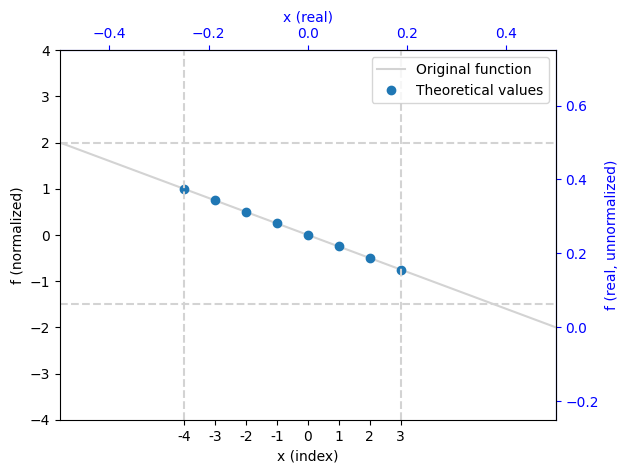

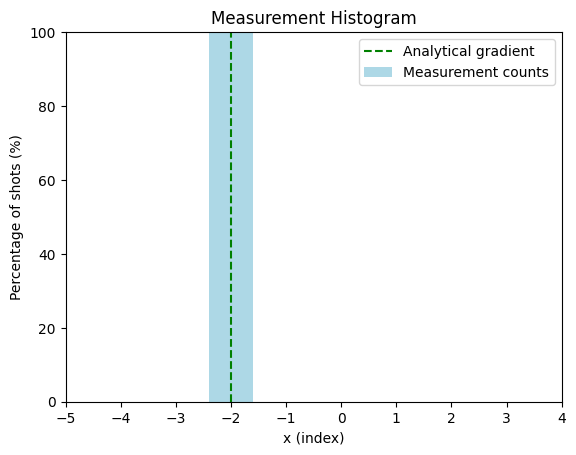

In [10]:
show_circuit = True  # Set to True to show the circuit

p = params()
p.set_function(p.linear, (-0.5, 0.25))
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))


qprog = synthesize(main)
if show_circuit:
    show(qprog)
job = execute(qprog)
# job.open_in_ide() # Uncomment to see the results in the IDE
pc = job.get_sample_result().parsed_counts
df = job.get_sample_result().dataframe

# You can use the helper function:
# pc, df = run_standard_simulation(main)

# Translate the majority state to a gradient value
majority_state = dict(df.iloc[0])
value = majority_state.get("x")
# Divide by (N/m) to get the actual gradient value.
majority_gradient = value / (N / m)
analytical_gradient = p.analytical_gradient(0)

# Or use the helper function:
# majority_gradient = state_to_gradient(majority_state.get('x'), p)

# Print the results and compute the majority gradient
print("Parsed counts:", pc)
print(f"The analytical gradient is: {analytical_gradient}")
print(f"The majority gradient is: {majority_gradient}")

# Check if the majority result is correct within the resolution of the algorithm
resolution = m / N
is_correct = abs(majority_gradient - analytical_gradient) < resolution / 2
print(f"The majority result is", "correct" if is_correct else "incorrect")
print("####################################################")

# Compute the success rate of the algorithm, i.e. the percentage of shots that are correct within the resolution of the algorithm.
success_rate, success_shots, total_shots = compute_success_rate(
    df, analytic_derivatives={"x": analytical_gradient}, p=p
)
print(f"Success rate: {success_rate:.2%} ({success_shots}/{total_shots} shots)")
show_bar(success_rate)

# Visualize the theoretical values of the phases
# We used the standard simulation, so this is theoretical values only without the phases from the simulation
plot_theoretical()

# Plot histogram of the results
plot_histogram(df, analytical_gradient=analytical_gradient)

# You can use the helper function:
# analyze_results(pc, df, p)

The result for the gradient is always a multiple of m/N.\
In the previous example, the gradient was -0.5, while the resolution (m/N) was 0.25.\
The gradient is a multiple of the resolution, and therefore the result can be exact, and the success rate was 100%.\
\
More complex case is where the gradient is not a multiple of the resolution.\
In those cases, the result will be a superposition of multiple solutions, but we can still get a good approximation for the gradient from the result.\
Let's see it in the next example.\
TODO: Consider removing this example, because it doesn't match the flow of the explanation.

Quantum program link: https://platform.classiq.io/circuit/3DIb2AIHYhra9keJamdJ86vntbo
Parsed counts: [{'x': 2}: 1781, {'x': 3}: 121, {'x': 1}: 67, {'x': -4}: 21, {'x': 0}: 16, {'x': -2}: 15, {'x': -1}: 15, {'x': -3}: 12]
The analytical gradient is: 0.55
The majority gradient is: 0.5
The majority result is correct
####################################################
Success rate: 86.96% (1781/2048 shots)
[███████████████████████████████████████████-------] 86.96%


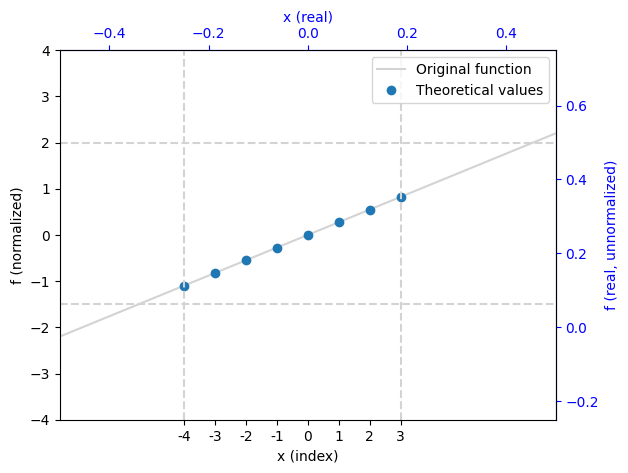

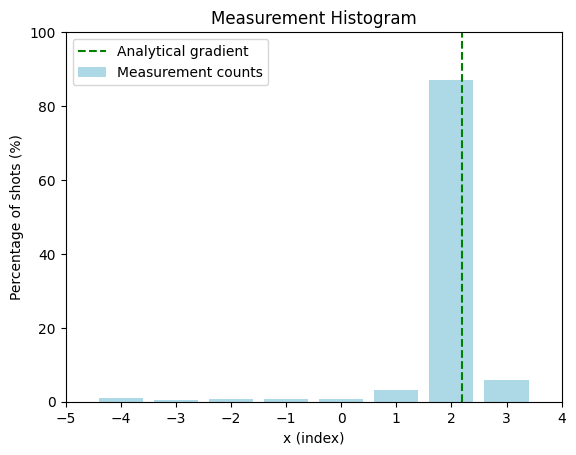

In [11]:
p = params()
# f(x) = 0.55*x + 0.25
# Gradient: f'(0) = 0.55
# Pay attention that 0.55 is not a multiple of m/N = 0.25,
# so we expect to get a superposition of multiple states around the correct gradient.
p.set_function(p.linear, (0.55, 0.25))
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))


pc, df = run_standard_simulation(main, show_circuit=True)
analyze_results(pc, df, p)

## 3.2. Quadratic Function

Again, let's try calculating the gradient of a non-linear function. In the next example, we will explore a quadratic function.\
In the case of non-linear function, we will need to cleverly choose the value of $l$ - the interval around the origin.\
In order for the algorithm to work, we need to work in the linear regime around the origin, so we need to choose small enough $l$.

First, for good selection of $l$, we see that the points are almost linear, and we get a good success rate.

Parsed counts: [{'x': 1}: 2021, {'x': 0}: 14, {'x': 2}: 10, {'x': 3}: 2, {'x': -2}: 1]
The analytical gradient is: 0.25
The majority gradient is: 0.25
The majority result is correct
####################################################
Success rate: 98.68% (2021/2048 shots)
[█████████████████████████████████████████████████-] 98.68%


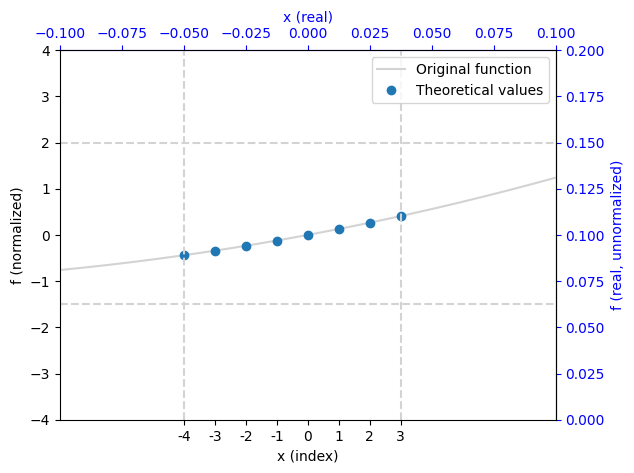

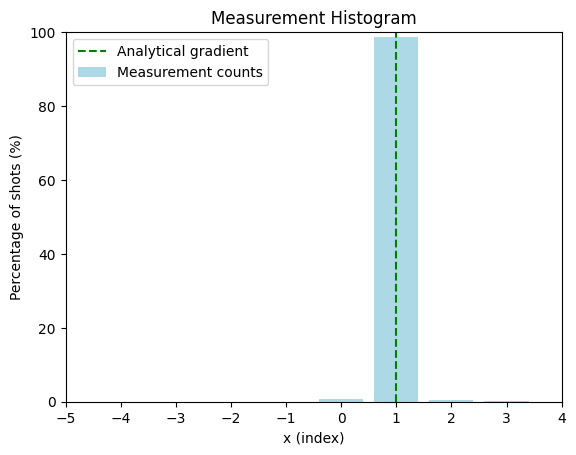

In [12]:
# In this example we will use the quadratic function
p = params()
# f(x) = 0.6*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = 1.2*x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.6, 0.25, 0.1))
# Setting l properly, ensuring we are in the linear regime of the function.
p.l = 0.1
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))


pc, df = run_standard_simulation(main)
analyze_results(pc, df, p)

But if we increase $l$ outside of the linear regime, we see that the success rate get drastically lower:

Parsed counts: [{'x': 2}: 497, {'x': 0}: 488, {'x': 1}: 486, {'x': -1}: 189, {'x': 3}: 188, {'x': -4}: 75, {'x': -2}: 65, {'x': -3}: 60]
The analytical gradient is: 0.25
The majority gradient is: 0.5
The majority result is incorrect
####################################################
Success rate: 23.73% (486/2048 shots)
[████████████--------------------------------------] 23.73%


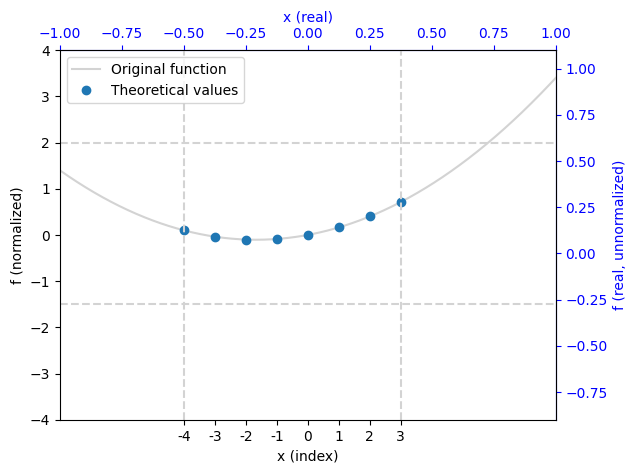

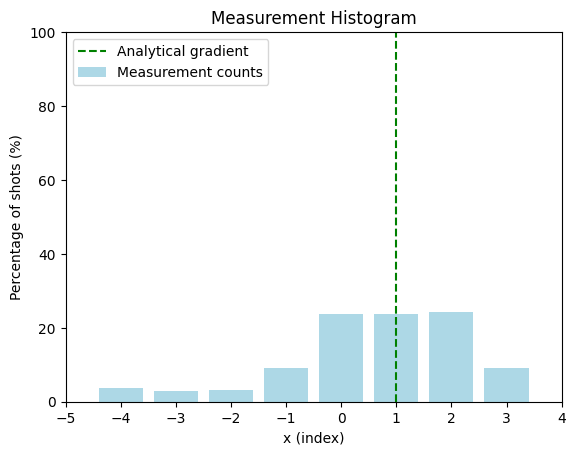

In [13]:
# In this example we will use the quadratic function
p = params()
# f(x) = 0.6*x^2 + 0.25*x + 0.1
# Gradient: f'(x) = 1.2*x + 0.25, so f'(0) = 0.25
p.set_function(p.quadratic, (0.6, 0.25, 0.1))
# Setting l to be too big, so we are outside of the linear regime of the function.
p.l = 1
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)

    # 2. QFT inverse on the coordinates register
    invert(lambda: qft(x))


pc, df = run_standard_simulation(main)
analyze_results(pc, df, p)

# 4. Parameters Selection - TODO

**TODO:** I moved the theoretical explanation to the top, so it will be removed from here.\
I'll need to rewrite the functions to use the $\nabla f_{max}$ and $\epsilon$ that I defined above.

## 4.1. Understanding the parameters

There are three main parameters to be selected: $l$, $m$ and $n$.\
$n$ is the number of bits of the result. The bigger $n$, the higher the accuracy of the result.\
$l$ is the interval size around the origin ($dx$).\
$m/2$ is the maximal gradient that can be calculated (in absolute value).

For the parameter $l$, we saw earlier that it should be selected such that we look at the linear regime of the function. See section 2.2.

Understanding the parameter $m$ is a little trickier. We will look at a bounding box around the origin.\
The width of the box (dx) is $l$, spanning from $-l/2$ to $l/2$. The slope of the graph (dy/dx) is bounded between $-m/2$ to $m/2$. Therefore, the height of the box (dy) should be bounded dy/dx*dx, so the height should be $lm/2$, making the box span between $-lm/4$ to $lm/4$.\
When we plot the graph, if all the points are inside this box, then we know that the gradient is bounded by $m/2$ and we will get the correct result.\
If the points are outside this box, we will get aliasing in the results and get an incorrect gradient.\
Note that in our graphs we use the normalized function instead of the original function, so the box is between $-N/4$ to $N/4$ instead of $lm/4$.

We will see now the same function, once with correct selection of m and one with incorrect selection of $m$, and we can see that if $m$ is too small the theoretical values are out of the bounding box, and the phases from the simulation are folded into the box creating aliasing. 

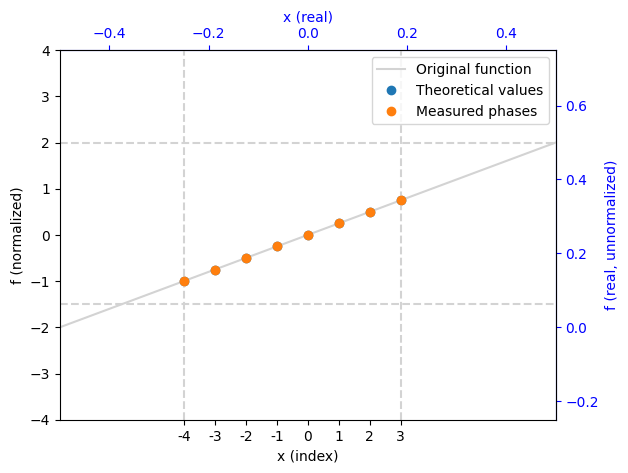

In [14]:
# In this example we will use the linear function
p = params()
p.set_function(p.linear, (0.5, 0.25))
p.m = 2  # Correct selection of m - no aliasing.
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)


df = run_statevector_simulation(main, print_circuit_info=False)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)
# simplified_df

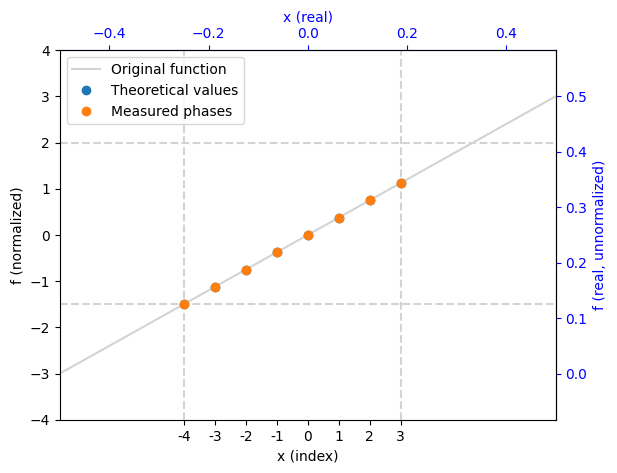

In [15]:
# In this example we will use the linear function
p = params()
p.set_function(p.linear, (0.5, 0.25))
p.m = 1.333  # Marginal selection of m - still no aliasing.
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)


df = run_statevector_simulation(main, print_circuit_info=False)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)
# simplified_df

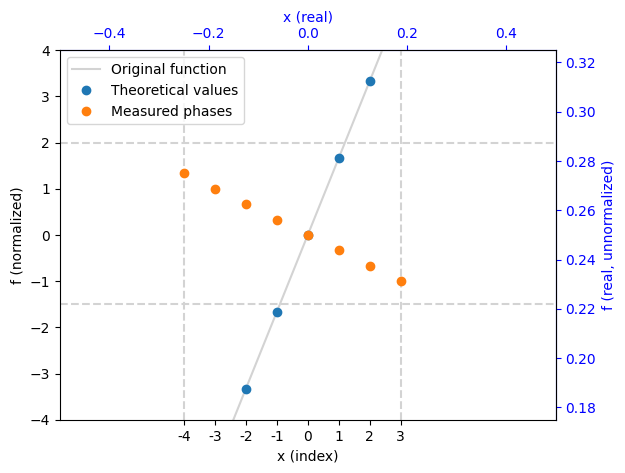

In [16]:
# In this example we will use the linear function
p = params()
p.set_function(p.linear, (0.5, 0.25))
p.m = 0.3  # Incorrect selection of m - aliasing occurs.
p.unpack(globals())


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]]):
    allocate(n, x)
    hadamard_transform(x)
    phase(f_normalized(x), 2 * pi)


df = run_statevector_simulation(main, print_circuit_info=False)
simplified_df = simplify_df(df)
plot_simplified_df(simplified_df)
# simplified_df

## 4.2. Success rate as function of parameter selection
**TODO**: consider removing this part

We can plot the success rate as a function of the selected parameters.\
In the first example, we will have a quadratic function $f(x)=0.6x^2+0.25x+0.1$, $f'(0)=0.25$.\
We can plot the graph for different selections of m.\
We discussed earlier that $m/2$ is the bound for the gradient value, so we expect to have poor results for $m<0.5$, good results for $m>0.5$, until reaching $m=0.25N=4$, where the resolution won't be good enough for meaningful result.\
Note the oscillations in the success rate in the optimal region. This is due to the discrete values the algorithm can return. As we increase the number of bits $n$, the oscillations will be smaller.

m=0.05: Success rate = 0.00%
m=0.1: Success rate = 0.00%
m=0.3: Success rate = 0.00%
m=0.5: Success rate = 9.47%
m=0.55: Success rate = 42.58%
m=0.7: Success rate = 87.74%
m=0.8: Success rate = 81.30%
m=0.9: Success rate = 91.70%
m=1.0: Success rate = 94.68%
m=1.5: Success rate = 72.41%
m=2.0: Success rate = 98.54%
m=3.0: Success rate = 0.00%
m=4.0: Success rate = 0.00%
m=6.0: Success rate = 0.00%
m=10.0: Success rate = 0.00%


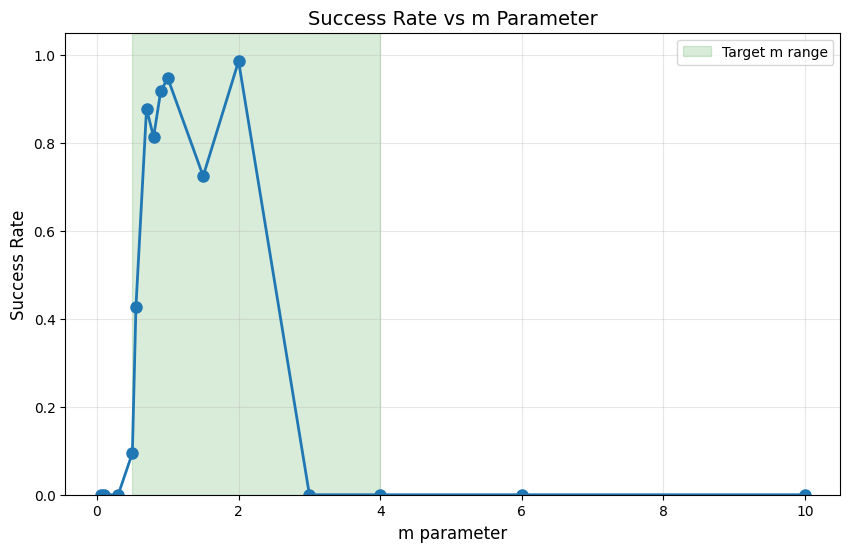

In [17]:
def plot_success_rate_vs_m(m_values, function, function_params, l_val=0.1, n_val=3):
    """
    Iterate over different m values and plot success rate as a function of m.

    Args:
        m_values: list of m values to test
        function: function name ("linear" / "quadratic") or callable
        function_params: parameters for the function
        l_val: l parameter (default 0.1)
        n_val: n parameter (default 3)
    """
    success_rates = []

    for m_val in m_values:
        p = params()
        p.m = m_val
        p.l = l_val
        p.n = n_val
        p.set_function(function, function_params)
        p.unpack(globals())

        @qfunc
        def main(x: Output[QNum[n, SIGNED, 0]]):
            allocate(n, x)
            hadamard_transform(x)
            phase(f_normalized(x), 2 * pi)
            invert(lambda: qft(x))

        pc, df = run_standard_simulation(main)
        analytic_grad = p.analytical_gradient(0)
        success_rate, _, _ = compute_success_rate(
            df,
            analytic_derivatives={"x": analytic_grad},
            p=p,
            tolerance=0.5 * analytic_grad,
        )
        success_rates.append(success_rate)
        print(f"m={m_val}: Success rate = {success_rate:.2%}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(m_values, success_rates, "o-", linewidth=2, markersize=8)
    plt.xlabel("m parameter", fontsize=12)
    plt.ylabel("Success Rate", fontsize=12)
    plt.title("Success Rate vs m Parameter", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1.05])
    ax = plt.gca()
    ax.axvspan(0.5, 4.0, color="green", alpha=0.15, label="Target m range")
    ax.legend()
    plt.show()
    return success_rates


# Example usage:
m_values = [
    0.05,
    0.1,
    0.3,
    0.5,
    0.55,
    0.7,
    0.8,
    0.9,
    1.0,
    1.5,
    2.0,
    3.0,
    4.0,
    6.0,
    10.0,
]
results = plot_success_rate_vs_m(m_values, "quadratic", (0.6, 0.25, 0.1))

As for the $l$ parameter, we need to be in the linear regime, so we need to ensure $l$ is small enough, as can be seen in the next example:

l=0.1: Success rate = 94.34%
l=0.2: Success rate = 78.96%
l=0.3: Success rate = 59.67%
l=0.4: Success rate = 39.31%
l=0.5: Success rate = 22.80%
l=1: Success rate = 10.60%
l=1.5: Success rate = 14.79%
l=2.0: Success rate = 14.55%
l=3.0: Success rate = 26.12%


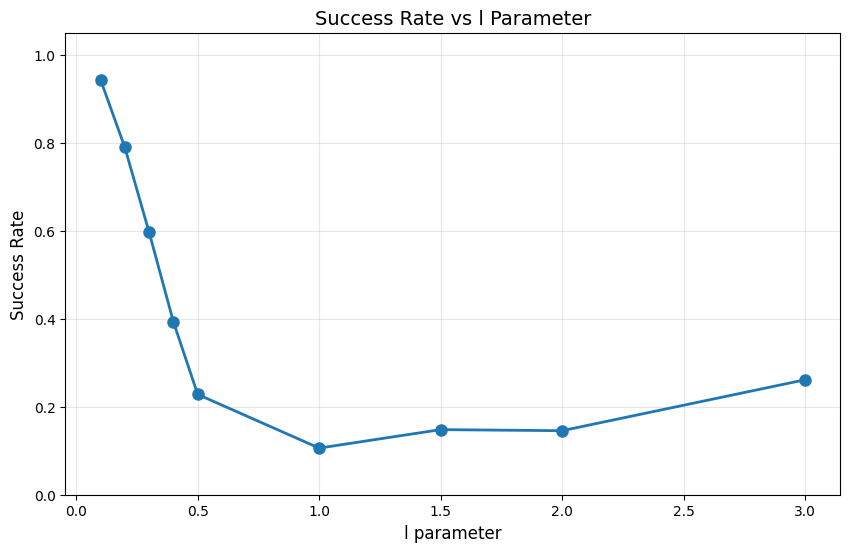

In [18]:
def plot_success_rate_vs_l(l_values, function, function_params, m_val=2.0, n_val=3):
    """
    Iterate over different l values and plot success rate as a function of l.

    Args:
        l_values: list of l values to test
        function: function name ("linear" / "quadratic") or callable
        function_params: parameters for the function
        m_val: m parameter (default 1.0)
        n_val: n parameter (default 3)
    """
    success_rates = []

    for l_curr in l_values:
        p = params()
        p.m = m_val
        p.l = l_curr
        p.n = n_val
        p.set_function(function, function_params)
        p.unpack(globals())

        @qfunc
        def main(x: Output[QNum[n, SIGNED, 0]]):
            allocate(n, x)
            hadamard_transform(x)
            phase(f_normalized(x), 2 * pi)
            invert(lambda: qft(x))

        pc, df = run_standard_simulation(main)
        analytic_grad = p.analytical_gradient(0)
        success_rate, _, _ = compute_success_rate(
            df, analytic_derivatives={"x": analytic_grad}, p=p
        )
        success_rates.append(success_rate)
        print(f"l={l_curr}: Success rate = {success_rate:.2%}")

    plt.figure(figsize=(10, 6))
    plt.plot(l_values, success_rates, "o-", linewidth=2, markersize=8)
    plt.xlabel("l parameter", fontsize=12)
    plt.ylabel("Success Rate", fontsize=12)
    plt.title("Success Rate vs l Parameter", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1.05])
    plt.show()

    return success_rates


# Example usage:
l_values = [0.1, 0.2, 0.3, 0.4, 0.5, 1, 1.5, 2.0, 3.0]
results_l = plot_success_rate_vs_l(
    l_values, "quadratic", (0.6, 0.25, 0.1), m_val=1.0, n_val=3
)

# 5. Multi-Coordinates Examples

This algorithm works in multiple dimensions too.\
We will now see an example in 2D, f(x,y).\
We will start with a linear and decoupled function $f(x,y)=ax+by+c$.

In [19]:
px = params()
py = params()

# Set the functions for x and y axes
# f(x, y) = a*x + b*y + c = 0.5*x - 0.25*y + 0.1
# df/dx = 0.5, df/dy = -0.25
a, b, c = 0.5, -0.25, 0.1
px.set_function(px.linear, (a, 0.0))
py.set_function(py.linear, (b, c))

# Important: we can't use the globals here, because there are two different functions for px and for py.


@qfunc
def main(x: Output[QNum[px.n, SIGNED, 0]], y: Output[QNum[py.n, SIGNED, 0]]):
    # State preparation for x-axis contribution
    allocate(px.n, x)
    hadamard_transform(x)
    phase(px.f_normalized(x), 2 * pi)

    # State preparation for y-axis contribution
    allocate(py.n, y)
    hadamard_transform(y)
    phase(py.f_normalized(y), 2 * pi)

    # Gradient extraction on each axis
    invert(lambda: qft(x))
    invert(lambda: qft(y))


pc, df = run_standard_simulation(main)
print(pc)

majority_state = dict(df.iloc[0])
gx_true = px.analytical_gradient(0)
gy_true = py.analytical_gradient(0)

gx_meas = (majority_state.get("x")) / (px.N / px.m)
gy_meas = (majority_state.get("y")) / (py.N / py.m)

print(f"Analytical gradient: (dx, dy) = ({gx_true}, {gy_true})")
print(f"Majority gradient:   (dx, dy) = ({gx_meas}, {gy_meas})")

success_rate, success_shots, total_shots = compute_success_rate(
    df, analytic_derivatives={"x": gx_true, "y": gy_true}, p=px
)
print(f"Success rate: {success_rate:.2%} ({success_shots}/{total_shots} shots)")
show_bar(success_rate)

[{'x': 2, 'y': -1}: 2048]
Analytical gradient: (dx, dy) = (0.5, -0.25)
Majority gradient:   (dx, dy) = (0.5, -0.25)
Success rate: 100.00% (2048/2048 shots)
[██████████████████████████████████████████████████] 100.00%


We can also have more complex example, with non-linear and coupled equation: $f(x, y)=ax^2+by^2+cxy+dx+ey+f$.

In [20]:
p = params()
p.l = 0.1
p.unpack(globals())


def f(x, y):
    a, b, c, d, e, f = 0.6, -0.4, 0.25, 0.25, -0.5, 0.1
    global gradient_x, gradient_y
    gradient_x = d
    gradient_y = e
    return a * x**2 + b * y**2 + c * x * y + d * x + e * y + f


# Generated functions
def f_normalized(x, y):
    val = f(l / N * x, l / N * y)
    val *= N / (l * m)
    return val


@qfunc
def main(x: Output[QNum[n, SIGNED, 0]], y: Output[QNum[n, SIGNED, 0]]):
    # 1. State preparation
    # Build arrays in two's complement binary order for prepare_complex_amplitudes.
    # Binary index i maps to signed value: i if i < N//2 else i - N
    idx = np.arange(N)
    x_signed = np.where(idx < N // 2, idx, idx - N)
    y_signed = np.where(idx < N // 2, idx, idx - N)

    # In order to use the prepare_complex_amplitudes function, we need to flatten the 2D arrays of magnitudes and phases into 1D arrays.
    X_grid, Y_grid = np.meshgrid(x_signed, y_signed, indexing="ij")
    phases_2d = f_normalized(X_grid, Y_grid) * 2 * np.pi
    magnitudes_2d = np.ones((N, N)) / N
    phases_flat = phases_2d.flatten().tolist()
    magnitudes_flat = magnitudes_2d.flatten().tolist()

    # Prepare the state using the flattened arrays, then bind the combined register to the x and y registers.
    combined_reg = QNum("combined_reg")
    prepare_complex_amplitudes(
        magnitudes=magnitudes_flat, phases=phases_flat, out=combined_reg
    )
    bind(combined_reg, [y, x])

    # 2. Next step in the algorithm: QFT inverse on the coordinates register
    invert(lambda: qft(x))
    invert(lambda: qft(y))


pc, df = run_standard_simulation(main)
print(pc)

majority_state = dict(df.iloc[0])
gx_true = gradient_x
gy_true = gradient_y

gx_meas = state_to_gradient(majority_state.get("x"), p)
gy_meas = state_to_gradient(majority_state.get("y"), p)

print(f"Analytical gradient: (dx, dy) = ({gx_true}, {gy_true})")
print(f"Majority gradient:   (dx, dy) = ({gx_meas}, {gy_meas})")

success_rate, success_shots, total_shots = compute_success_rate(
    df, analytic_derivatives={"x": gx_true, "y": gy_true}, p=p
)
print(f"Success rate: {success_rate:.2%} ({success_shots}/{total_shots} shots)")
show_bar(success_rate)

[{'x': 1, 'y': -2}: 1993, {'x': 0, 'y': -2}: 18, {'x': 2, 'y': -2}: 9, {'x': 1, 'y': -1}: 8, {'x': 1, 'y': -3}: 4, {'x': -2, 'y': -2}: 4, {'x': 0, 'y': -1}: 3, {'x': 2, 'y': -1}: 2, {'x': 1, 'y': -4}: 1, {'x': -1, 'y': 3}: 1, {'x': 0, 'y': 3}: 1, {'x': 0, 'y': -4}: 1, {'x': -4, 'y': -2}: 1, {'x': 3, 'y': 3}: 1, {'x': -1, 'y': -2}: 1]
Analytical gradient: (dx, dy) = (0.25, -0.5)
Majority gradient:   (dx, dy) = (0.25, -0.5)
Success rate: 97.31% (1993/2048 shots)
[█████████████████████████████████████████████████-] 97.31%


# References

In [21]:
# TODO: add